# Simple model

We simulate bursts with N=1 component and infer one parameter, the peak time (`t0`) with MCMC and normalizing flows.

In [1]:
import sys
sys.path.append('..')

import emcee
import numpy as np
import math 
import matplotlib.pyplot as plt
from typing import Iterable

from src.helpers import twoexp, combined_twoexp, simulate_burst, plot_simulated_burst, plot_trace

In [2]:
time = np.linspace(0, 1.0, 1000)
N = 1
amp = 10.0
t0 = 0.4
rise = 0.03
skew = 5.0

ybkg = 5.0

x_model, x_counts = simulate_burst(
    time=time,
    ncomp=N,
    burstparams=[t0, amp, rise, skew],
    ybkg=ybkg,
    return_model=True
)

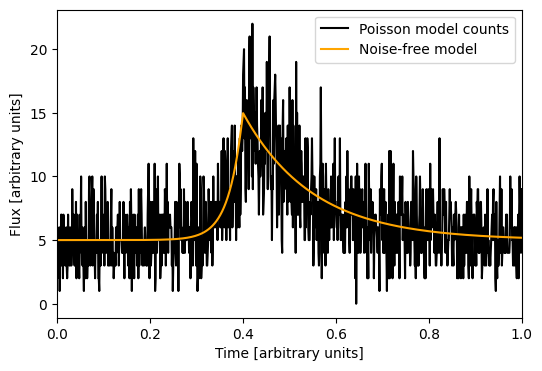

In [3]:
plot_simulated_burst(time, x_counts, x_model)
plt.show()

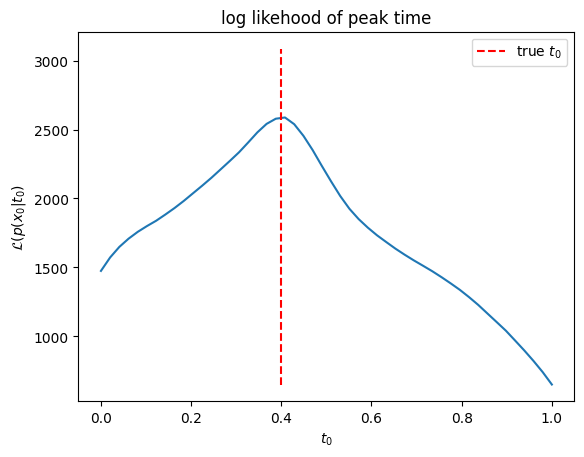

In [4]:
def log_likelihood(t0: float, x_counts: Iterable[int]) -> float:
    """
    $ln(p(x_{counts} | t0)$
    natural logarithm of poisson likelihood.
    """
    
    L = 0
    # true rate 
    model_counts = combined_twoexp(time, [t0], [amp], [rise], [skew], ybkg)

    L = (
        -1 * np.sum(np.log(model_counts)) 
        + np.sum(x_counts * np.log(model_counts)) 
        - np.sum([math.log(math.factorial(x)) for x in x_counts]) # Note x is simulated count and should always be integer
    )
    
    # TODO: Compare w/ likelihood function of Daniela
    return L

true_t0 = t0
t0s = np.linspace(0, 1, 50)
likelihoods = [log_likelihood(t0, x_counts) for t0 in t0s]
plt.plot(t0s, likelihoods)
plt.title("log likehood of peak time")
plt.ylabel("$\mathcal{L}(p(x_0 | t_0)$")
plt.xlabel("$t_0$")
plt.vlines([true_t0],  ymin=min(likelihoods), ymax=max(likelihoods) + 500, linestyles="dashed", color ='red', label='true $t_0$')
plt.legend()
plt.show()


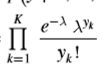

In [12]:
nwalkers = 20
ndim = 1
p0 = np.random.rand(nwalkers, ndim) # initial position of the walkers

def log_prob(t0: Iterable[float], *args) -> float:
    """
    Log of the posterior distribution.
    """
    # t0 is bounded by the uniform prior
    if t0 < 0 or t0 > 1:
        return -np.inf
    
    # otherwise its equal to the likelihood
    return log_likelihood(t0, *args)

# https://emcee.readthedocs.io/en/stable/tutorials/quickstart/
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=[x_counts])

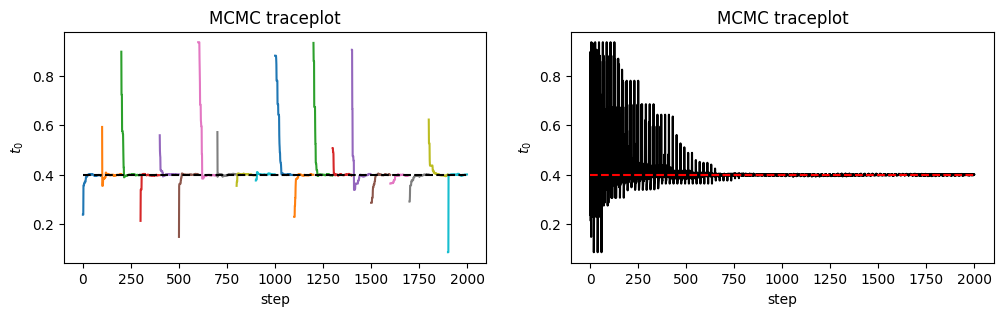

In [13]:
# burn-in 
burn_steps = 100
state = sampler.run_mcmc(p0, burn_steps)
plot_trace(sampler, burn_steps, true_t0)
sampler.reset()

In [14]:
steps = 1000
sampler.run_mcmc(state, 1000)

State([[0.40076847]
 [0.39939958]
 [0.39785058]
 [0.40084478]
 [0.39800319]
 [0.40173124]
 [0.39959438]
 [0.40391481]
 [0.39923155]
 [0.39773681]
 [0.40121567]
 [0.39813683]
 [0.39994883]
 [0.39938861]
 [0.39827708]
 [0.40177916]
 [0.39836396]
 [0.3972661 ]
 [0.39886166]
 [0.3999394 ]], log_prob=[2568.41973957 2568.6294996  2568.04367947 2568.38614847 2568.10750789
 2567.91372482 2568.60810467 2566.07327453 2568.55982936 2567.99896294
 2568.23935861 2568.16700931 2568.58811858 2568.62488222 2568.23308531
 2567.87743825 2568.27588064 2567.79796383 2568.42515239 2568.58833379], blobs=None, random_state=('MT19937', array([3670154431, 3197447340, 4139593642,  409832187, 1673493727,
       4051535574,   78084515, 1339978878, 1880660065, 4145503812,
       1538491025, 4255120749, 3696974776, 3482258923, 3766517103,
       1235859271, 1658651131, 1373925449, 1139956592,  324003756,
       1648735069, 3564980536, 1756366201, 4070234843,  682715941,
        959862456, 1683796273, 3627664131, 22

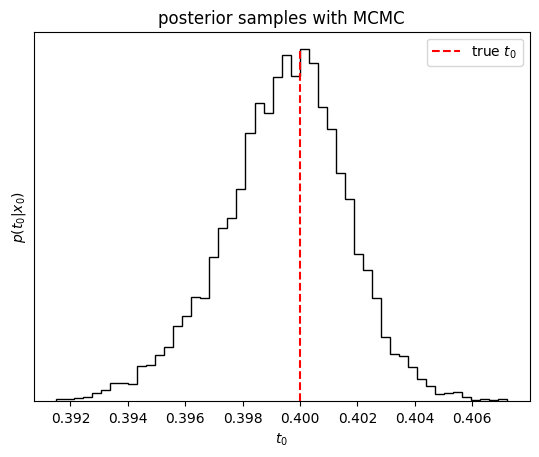

In [15]:
samples = sampler.get_chain(flat=True)

frequencies, _, _ = plt.hist(samples[:, 0], 50, color="k", histtype="step")
plt.vlines([true_t0],  ymin=0, ymax=max(frequencies), linestyles="dashed", color ='red', label='true $t_0$')

plt.title("posterior samples with MCMC")
plt.xlabel("$t_0$")
plt.ylabel("$p(t_0 | x_0)$")
plt.gca().set_yticks([])

plt.legend()
plt.show()

In [16]:
print(
    "Mean acceptance fraction: {0:.3f}".format(
        np.mean(sampler.acceptance_fraction)
    )
)

# TODO: Diagnose mcmc Trace plots chains as a func of iteration (ideally should be white noise)
# Autocorrelation time check
# add plots where you overlay samples from the posterior on the data

Mean acceptance fraction: 0.796


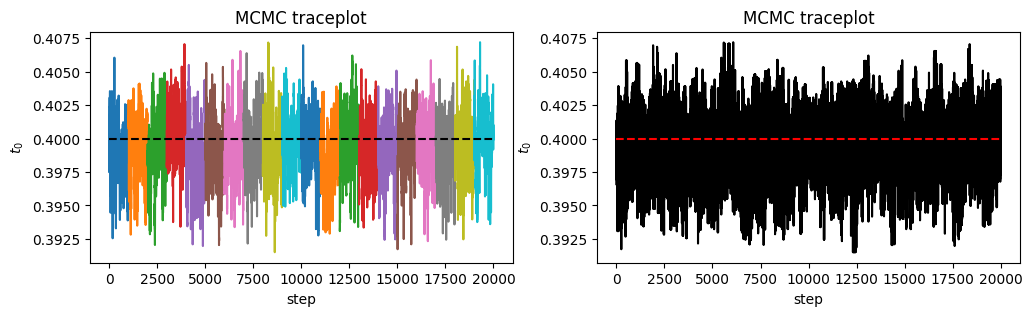

In [17]:
# trace plot
plot_trace(sampler, steps, true_t0)
plt.show()

# Two peaks

In [84]:
time = np.linspace(0, 1, 1000)
N = 2
amp = 16.0
t0 = 0.1
rise = 0.03
skew = 5.0

ybkg = 5.0

t0_l = [t0, t0+0.5]
rise_l = [rise, rise]
amp_l = [amp, amp] 
skew_l = [skew, skew] 

burstparams = np.array([t0_l, amp_l, rise_l, skew_l]).flatten()

x_model, x_counts = simulate_burst(
    time=time,
    ncomp=N,
    burstparams=burstparams,
    ybkg=ybkg,
    return_model=True
)

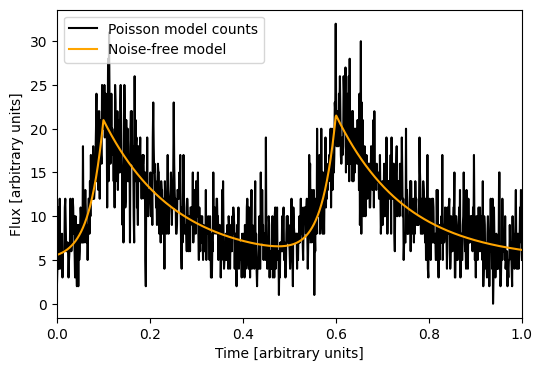

In [85]:
plot_simulated_burst(time, x_counts, x_model)
plt.show()

In [86]:
nwalkers = 20
ndim = 2
p0 = np.sort(np.random.rand(nwalkers, ndim), axis=1) # initial position of the walkers, SAMPLE FROM THE PRIOR, SO ENSURE t0_1 < t0_2

def log_likelihood(t0, x_counts):
    """
    $ln(p(x_{counts} | t0)$
    natural logarithm of poisson likelihood.
    """
    
    L = 0
    # true rate 
    model_counts = combined_twoexp(time, t0, [amp, amp], [rise, rise], [skew, skew], ybkg)

    L = (
        -1 * np.sum(np.log(model_counts)) 
        + np.sum(x_counts * np.log(model_counts)) 
        - np.sum([math.log(math.factorial(x)) for x in x_counts]) # TODO: If x is float, change m.factorial(x), m.gamma(x + 1)
    )
    
    # TODO: Compare w/ likelihood function of Daniela
    return L

is_sorted = lambda a: np.all(a[:-1] <= a[1:])

def log_prob(t0, *args):
    """
    Log of the posterior distribution.
    """
    # t0 is bounded by the uniform prior
    if t0.any() < 0 or t0.any() > 1:
        return -np.inf
        
    # peak time of first peak should be smaller than second peak etc. etc.
    # if not np.all(np.diff(t0) > 0):
    #     return -np.inf
    
    if t0[0] > t0[1]:
        return -np.inf
    
    # otherwise its equal to the likelihood
    return log_likelihood(t0, *args)

# https://emcee.readthedocs.io/en/stable/tutorials/quickstart/
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=[x_counts])

In [87]:
# burn-in of 100 steps
burn_steps = 300
steps = 2000

sampler.reset()
state = sampler.run_mcmc(p0, burn_steps)

sampler.reset()
sampler.run_mcmc(state, steps)

State([[0.09755063 0.59233931]
 [0.09727365 0.59768271]
 [0.09858358 0.59690705]
 [0.10131161 0.59634777]
 [0.09940627 0.59801132]
 [0.09753626 0.5993164 ]
 [0.10131068 0.59363964]
 [0.09910412 0.59729308]
 [0.09966796 0.59490494]
 [0.09761498 0.59746308]
 [0.09731648 0.59582098]
 [0.09751987 0.59663206]
 [0.09915433 0.59263926]
 [0.10174359 0.5957796 ]
 [0.09903613 0.59655425]
 [0.0998372  0.59518183]
 [0.09870224 0.59815789]
 [0.09792835 0.59602416]
 [0.09897909 0.59187509]
 [0.09643096 0.59829387]], log_prob=[5677.9486613  5678.39045511 5679.06342903 5678.04601432 5678.59044397
 5677.20764043 5677.6937658  5679.0452469  5679.00622313 5678.63822961
 5678.75588474 5678.81645688 5678.47183736 5677.63808435 5679.23525376
 5678.9860605  5678.54162616 5679.05112366 5678.06465088 5677.21082657], blobs=None, random_state=('MT19937', array([3967373331, 1061868191, 2322677486,  265127830,  855911394,
       3189081435, 3576292322, 2428657852,  235466072,  945754786,
       1550035536,  695158

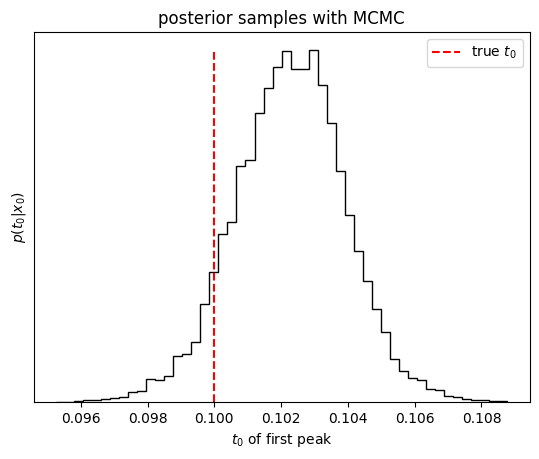

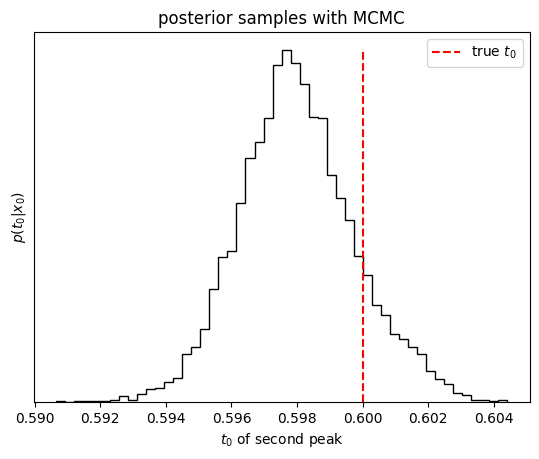

array([[0.10243875, 0.59761238],
       [0.10200684, 0.59791453],
       [0.10380765, 0.59583027],
       ...,
       [0.10323528, 0.59652887],
       [0.10059614, 0.59844404],
       [0.1007614 , 0.59946071]])

In [ ]:
samples = sampler.get_chain(flat=True)

frequencies, _, _ = plt.hist(samples[:, 0], 50, color="k", histtype="step")
plt.vlines([0.1],  ymin=0, ymax=max(frequencies), linestyles="dashed", color ='red', label='true $t_{0}$')

plt.title("posterior samples with MCMC")
plt.xlabel("$t_0$ of first peak")
plt.ylabel("$p(t_0 | x_0)$")
plt.gca().set_yticks([])

plt.legend()
plt.show()

frequencies, _, _ = plt.hist(samples[:, 1], 50, color="k", histtype="step")
plt.vlines([0.6],  ymin=0, ymax=max(frequencies), linestyles="dashed", color ='red', label='true $t_{0}$')

plt.title("posterior samples with MCMC")
plt.xlabel("$t_0$ of second peak")
plt.ylabel("$p(t_0 | x_0)$")
plt.gca().set_yticks([])

plt.legend()
plt.show()

samples

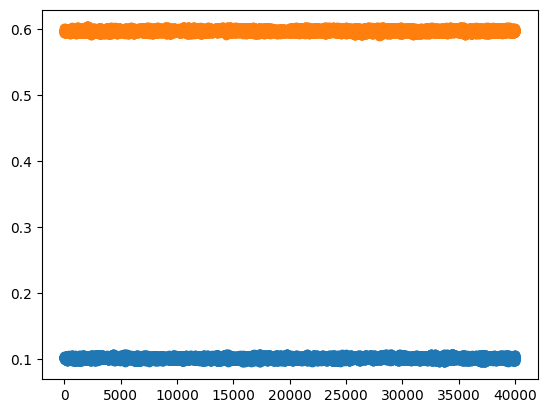

In [81]:
plt.plot(sampler.get_chain(flat=True), 'o')

In [60]:
# Normalizing flow

# generate bunch of training data (all params fixed except t0?)

# generate posterior using normalizing flow ?

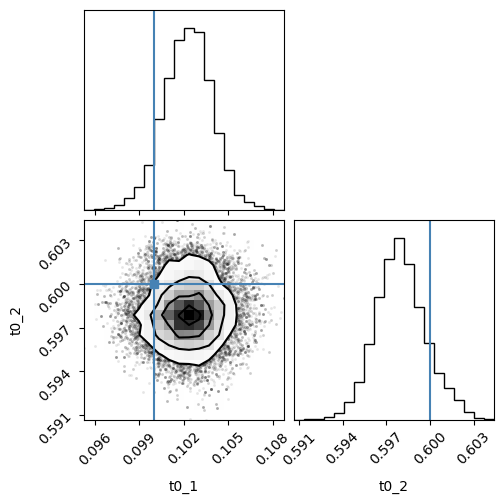

In [ ]:
from corner import corner

fig = corner(samples, labels=["t0_1", "t0_2"], truths=[0.1, 0.6])

In [34]:
tau = sampler.get_autocorr_time()
print(tau)

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 40;
tau: [42.47109727 42.6818976 ]

Text(0.5, 0, 'step number')

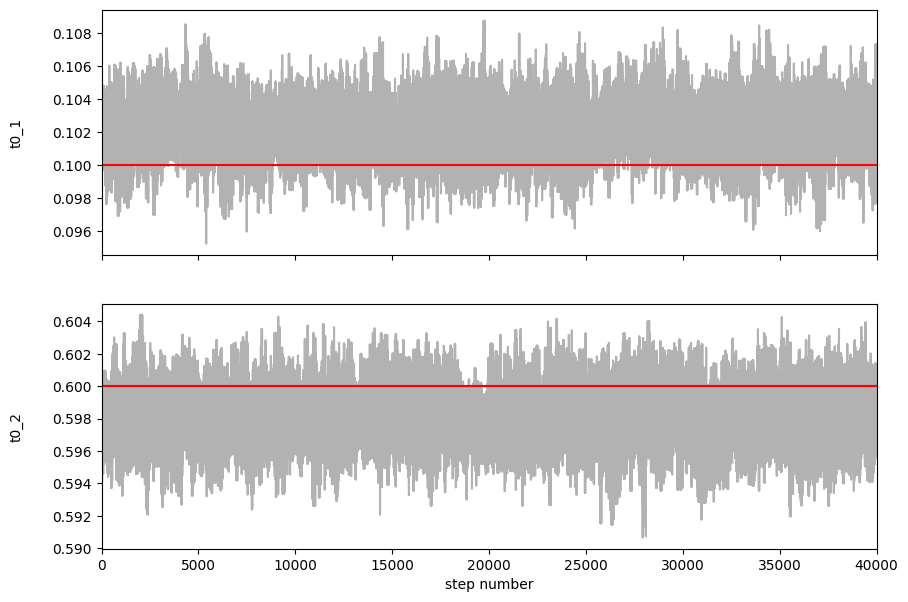

In [ ]:
fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)
labels = ["t0_1", "t0_2"]

for i in range(2):
    ax = axes[i]
    ax.plot(samples[:, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.hlines([t0_l[i]], xmin=0, xmax=2*nwalkers*steps, color='red')
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")

In [ ]:
# Draw samples from posterior and overlay onto simulated data
# get t01 and t02 from the samples from the sampler and 